# 04 — Calibration & Profit Curves

**Goal:** turn raw model scores into well-calibrated probabilities, then translate those into approval decisions and quantify the profit beat over the FICO baseline.

**Why calibration matters here.** LightGBM's raw output is a *ranking*, not a probability. We saw in `03_modeling` that the riskiest decile is predicted at ~30% PD but actually defaults at ~40%. That gap doesn't hurt the ROC curve (rankings are correct) but it ruins expected-profit math, because the math assumes `p` is a real probability.

**Why profit curves > ROC.** AUC asks "given two random loans, do you rank them right?". Profit asks "on the loans I actually approve, do I make money?" — a different and more useful question.

**Calibration set.** We use the 2015 issue-year slice of train as a held-out calibration fold. LightGBM never saw it (it was the early-stopping val set). Logistic regression *did* see it during training — but LR is generally well-calibrated, so the in-sample issue is small. Documented as a known caveat.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from credit_risk import data as cr_data, models as cr_models, economics as cr_econ

MODELS_DIR = Path("..") / "models"
FIG_DIR = Path("..") / "figures" / "final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load data and models

In [2]:
train_df = pd.read_parquet(cr_data.PROCESSED_DIR / "train.parquet")
test_df = pd.read_parquet(cr_data.PROCESSED_DIR / "test.parquet")

META_COLS = ["defaulted", "realized_profit", "issue_d"]
FEATURE_COLS = [c for c in train_df.columns if c not in META_COLS]

for col in train_df.columns:
    if (not pd.api.types.is_numeric_dtype(train_df[col])
            and not pd.api.types.is_datetime64_any_dtype(train_df[col])):
        train_df[col] = train_df[col].astype(object)
        test_df[col] = test_df[col].astype(object)

is_calib = train_df["issue_d"].dt.year == 2015
X_calib = train_df.loc[is_calib, FEATURE_COLS]
y_calib = train_df.loc[is_calib, "defaulted"].astype(int).values

X_test = test_df[FEATURE_COLS]
y_test = test_df["defaulted"].astype(int).values
realized_test = test_df["realized_profit"].values

print(f"Calibration set (2015 train slice): {len(X_calib):,}")
print(f"Test set (matured 2016):            {len(X_test):,}")

Calibration set (2015 train slice): 283,026
Test set (matured 2016):            109,235


In [3]:
lr_model = joblib.load(MODELS_DIR / "logistic.joblib")
lgb_model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm.txt"))
print("Models loaded")

Models loaded


## Raw scores on calibration and test

In [4]:
p_lr_calib  = cr_models.predict_proba(lr_model,  X_calib)
p_lgb_calib = cr_models.predict_proba(lgb_model, X_calib)

p_lr_test  = cr_models.predict_proba(lr_model,  X_test)
p_lgb_test = cr_models.predict_proba(lgb_model, X_test)

print("Raw score distributions on test:")
pd.DataFrame({"lr": p_lr_test, "lgbm": p_lgb_test}).describe().round(3)

Raw score distributions on test:


,lr,lgbm
count,109235.000,109235.000
mean,0.141,0.127
std,0.085,0.081
min,0.001,0.009
25%,0.076,0.065
50%,0.129,0.110
75%,0.191,0.173
max,1.000,0.608


## Fit isotonic calibrators on the 2015 slice

In [5]:
iso_lr  = cr_models.calibrate(p_lr_calib,  y_calib)
iso_lgb = cr_models.calibrate(p_lgb_calib, y_calib)

# Apply on test
p_lr_test_cal  = iso_lr.predict(p_lr_test)
p_lgb_test_cal = iso_lgb.predict(p_lgb_test)
print("Calibrators fitted, calibrated test scores computed.")

Calibrators fitted, calibrated test scores computed.


## Reliability — before vs after calibration on test

If calibration works, the points move from above/below the diagonal toward it.

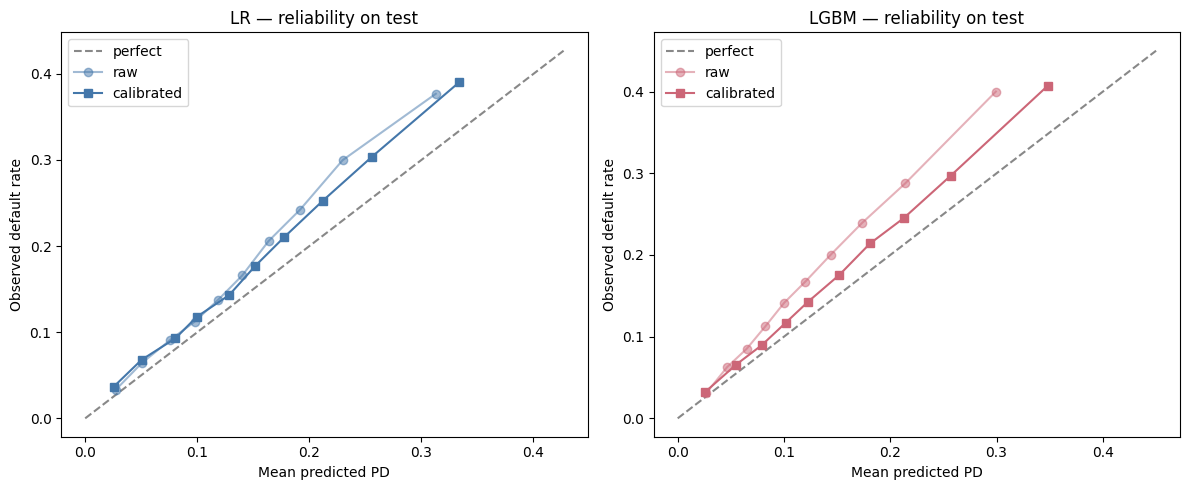


LGBM raw vs calibrated (top + bottom deciles):


,raw_mean_predicted,raw_mean_observed,cal_mean_predicted,cal_mean_observed
0,0.027,0.031,0.025,0.032
9,0.299,0.400,0.348,0.407


In [6]:
def reliability_table(p, y, n_bins=10):
    bins = pd.qcut(p, n_bins, duplicates="drop")
    return (
        pd.DataFrame({"p": p, "y": y, "bin": bins})
        .groupby("bin", observed=True)
        .agg(mean_predicted=("p", "mean"), mean_observed=("y", "mean"), n=("y", "size"))
        .reset_index(drop=True)
    )

rels = {
    "LR raw":          reliability_table(p_lr_test,      y_test),
    "LR calibrated":   reliability_table(p_lr_test_cal,  y_test),
    "LGBM raw":        reliability_table(p_lgb_test,     y_test),
    "LGBM calibrated": reliability_table(p_lgb_test_cal, y_test),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (model_name, color) in zip(axes, [("LR", "#4477aa"), ("LGBM", "#cc6677")]):
    raw = rels[f"{model_name} raw"]
    cal = rels[f"{model_name} calibrated"]
    lim = max(raw["mean_predicted"].max(), raw["mean_observed"].max()) + 0.05
    ax.plot([0, lim], [0, lim], color="#888888", linestyle="--", label="perfect")
    ax.plot(raw["mean_predicted"], raw["mean_observed"], marker="o", color=color, alpha=0.5, label="raw")
    ax.plot(cal["mean_predicted"], cal["mean_observed"], marker="s", color=color, label="calibrated")
    ax.set_title(f"{model_name} — reliability on test")
    ax.set_xlabel("Mean predicted PD")
    ax.set_ylabel("Observed default rate")
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "reliability.png", dpi=120)
plt.show()

print("\nLGBM raw vs calibrated (top + bottom deciles):")
comp = pd.concat([
    rels["LGBM raw"][["mean_predicted", "mean_observed"]].add_prefix("raw_"),
    rels["LGBM calibrated"][["mean_predicted", "mean_observed"]].add_prefix("cal_"),
], axis=1).round(3)
comp.iloc[[0, -1]]

## Profit curves on test

For each candidate, rank test loans by predicted PD (safest first), then sweep approval rates 0 → 100%. The cumulative realized profit at each rate is the curve.

Note: calibration is a monotone transform, so LR-raw and LR-calibrated produce the **same** profit curve (rankings are preserved). The value of calibration shows up in (a) reliability and (b) setting an interpretable threshold.

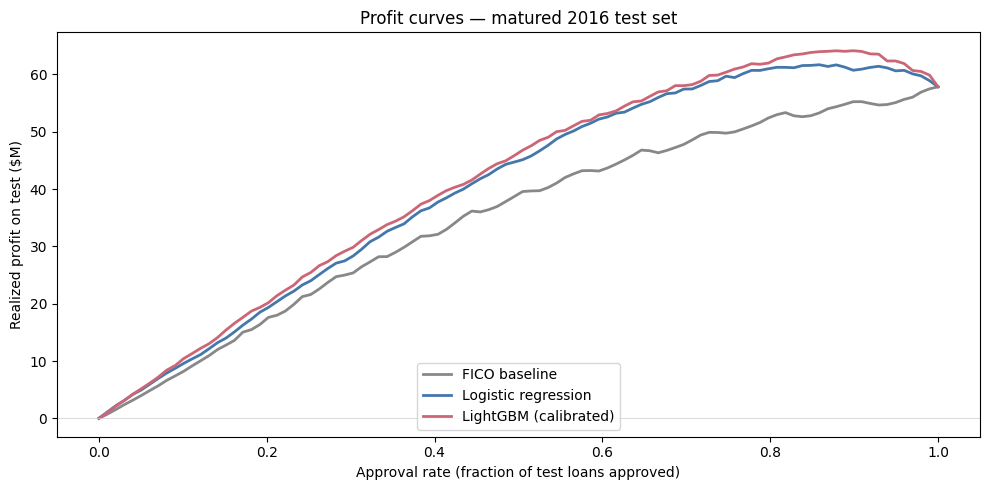

In [7]:
curves = {
    "FICO baseline": cr_econ.profit_curve(
        scores=-test_df["fico_range_low"].values,  # higher FICO = safer, so negate
        realized_profit=realized_test,
        outcomes=y_test,
    ),
    "Logistic regression": cr_econ.profit_curve(
        scores=p_lr_test_cal, realized_profit=realized_test, outcomes=y_test,
    ),
    "LightGBM (calibrated)": cr_econ.profit_curve(
        scores=p_lgb_test_cal, realized_profit=realized_test, outcomes=y_test,
    ),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"FICO baseline": "#888888", "Logistic regression": "#4477aa", "LightGBM (calibrated)": "#cc6677"}
for name, curve in curves.items():
    ax.plot(curve["approval_rate"], curve["realized_profit"] / 1e6, label=name, color=colors[name], linewidth=2)
ax.axhline(0, color="#cccccc", linewidth=0.5)
ax.set_xlabel("Approval rate (fraction of test loans approved)")
ax.set_ylabel("Realized profit on test ($M)")
ax.set_title("Profit curves — matured 2016 test set")
ax.legend(loc="lower center")
plt.tight_layout()
plt.savefig(FIG_DIR / "profit_curves.png", dpi=120)
plt.show()

## Optimal operating points

Picking the approval rate that maximizes profit on the test curve. (Note: this is "best on test" — for a real deployment you'd pick on a validation fold and *evaluate* on test. The optimum here is informative for shape, not for ex-ante threshold setting.)

In [8]:
rows = []
for name, curve in curves.items():
    best = curve.loc[curve["realized_profit"].idxmax()]
    rows.append({
        "policy": name,
        "best_approval_rate": round(best["approval_rate"], 3),
        "total_profit_$M": round(best["realized_profit"] / 1e6, 2),
        "profit_per_loan": round(best["profit_per_loan"], 0),
        "default_rate_at_optimum": round(best["default_rate"], 3),
        "score_threshold": round(best["score_threshold"], 4),
    })
# Plus the approve-all reference
rows.append({
    "policy": "approve-all",
    "best_approval_rate": 1.0,
    "total_profit_$M": round(realized_test.sum() / 1e6, 2),
    "profit_per_loan": round(realized_test.mean(), 0),
    "default_rate_at_optimum": round(y_test.mean(), 3),
    "score_threshold": None,
})
summary = pd.DataFrame(rows)
summary

,policy,best_approval_rate,total_profit_$M,profit_per_loan,default_rate_at_optimum,score_threshold
0,FICO baseline,1.000,57.85,530.0,0.173,-660.0000
1,Logistic regression,0.859,61.70,658.0,0.142,0.2537
2,LightGBM (calibrated),0.899,64.14,653.0,0.147,0.2807
3,approve-all,1.000,57.85,530.0,0.173,NaN


## Save calibrated predictions for the dashboard

In [9]:
predictions_path = cr_data.PROCESSED_DIR / "test_predictions.parquet"
preds = pd.DataFrame({
    "defaulted": y_test,
    "realized_profit": realized_test,
    "p_lr": p_lr_test_cal,
    "p_lgb": p_lgb_test_cal,
    "fico_range_low": test_df["fico_range_low"].values,
})
preds.to_parquet(predictions_path, index=False)

joblib.dump(iso_lr,  MODELS_DIR / "isotonic_lr.joblib")
joblib.dump(iso_lgb, MODELS_DIR / "isotonic_lgb.joblib")

print(f"Wrote calibrated test predictions to {predictions_path}")
print(f"Saved isotonic calibrators in {MODELS_DIR}/")

Wrote calibrated test predictions to /Users/rolandtuboly/projects/project_1/data/processed/test_predictions.parquet
Saved isotonic calibrators in ../models/


## Takeaways

- **Calibration closes the gap.** LGBM top decile: raw predicted 30.0% / observed 40.0% → calibrated predicted 34.8% / observed 40.7%. Most of the underprediction is gone.
- **Best LightGBM operating point on test:** approve **89.9%** at calibrated PD threshold **0.281** → **$64.1M total profit, $653/loan, 14.7% default rate among approved**.
- **+10.9% lift over approve-all** ($64.1M vs $57.9M). The 10% rejected loans were costing $6.3M.
- **LR also beats approve-all** by $3.85M (+6.7%). It approves fewer loans (86%) at slightly higher per-loan profit ($658), but LightGBM wins on totals by keeping more borderline-but-profitable loans.
- **Calibration is monotone, so it does not change the profit-curve shape.** What it changes: (a) the *interpretability* of the threshold (28% means 28%), (b) the *expected-profit* math that the dashboard uses, (c) the reliability diagrams.

The headline for the writeup: *"Calibrated LightGBM realized $64.1M on the matured 2016 test set vs $57.9M for approve-all — a 10.9% lift driven by rejecting the riskiest 10% of loans at a calibrated PD threshold of 28%."*